In [175]:
import matplotlib as mpl

mpl.rcParams.update({

    # -------- Lines --------
    "lines.linewidth": 2,
    "lines.markersize": 4.5,

    # -------- Axes labels --------
    "axes.labelsize": 14,
    "axes.titlesize": 14,

    # -------- Tick labels --------
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,

    # -------- Legend --------
    "legend.fontsize": 11,

    # -------- Grid --------
    "grid.alpha": 0.25,

})

plot A Function

In [176]:
def plot_hp_g_top(ax):
    """
    HP — compare equal-sized G-distributions for L=15 and L=25,
    styled like the biomorph comparison panel.
    """
    import numpy as np
    import pandas as pd
    from pathlib import Path

    rng = np.random.default_rng(42)

    # ----------------------------------------------------------
    # Files
    # ----------------------------------------------------------
    l15_file = Path(
        "/Users/sam/Documents/Oxford/Physics/sloppiness/"
        "circadian/mut_project_updates/figures/forsam3/HP_sizes/"
        "random_sample_mc_n15.txt"
    )

    l25_file = Path(
        "/Users/sam/Documents/Oxford/Physics/sloppiness/"
        "circadian/mut_project_updates/figures/HP/plot_a/plot_a_files/"
        "unified_plotA_B_D.txt"
    )

    # ----------------------------------------------------------
    # Helper
    # ----------------------------------------------------------
    def load_complexity(file_path, complexity_col=None, random_only=False):
        df = pd.read_csv(file_path, sep=r"\s+", low_memory=False)
        df.columns = df.columns.str.strip()

        if random_only and "mutation_type" in df.columns:
            df = df[df["mutation_type"] == "Random_Sample"].copy()

        if complexity_col is None:
            if "KC" in df.columns:
                complexity_col = "KC"
            elif "KCComplexity" in df.columns:
                complexity_col = "KCComplexity"
            else:
                raise ValueError(f"Couldn't find complexity column in {file_path}")

        x = pd.to_numeric(df[complexity_col], errors="coerce").dropna().to_numpy()
        x = x[x > 0]
        return x

    # ----------------------------------------------------------
    # Load datasets
    # ----------------------------------------------------------
    L15 = load_complexity(l15_file, complexity_col="KC")
    L25_full = load_complexity(l25_file, complexity_col="KCComplexity", random_only=True)

    print(f"L=15 available genotypes : {len(L15):,}")
    print(f"L=25 available genotypes : {len(L25_full):,}")

    # ----------------------------------------------------------
    # Equal-size comparison
    # ----------------------------------------------------------
    L25 = L25_full

    print("\nComparison datasets:")
    print(f"  L=15 : using all {len(L15):,} genotypes")
    print(f"  L=25 : using all {len(L25):,} available genotypes")

    print("\nMean complexities:")
    print(f"  L=15 : {L15.mean():.3f}")
    print(f"  L=25 : {L25.mean():.3f}")

    # ----------------------------------------------------------
    # Shared bins
    # ----------------------------------------------------------
    all_values = np.concatenate([L15, L25])

    bin_width = 3
    bins = np.arange(
        np.floor(all_values.min() / bin_width) * bin_width,
        np.ceil(all_values.max() / bin_width) * bin_width + bin_width,
        bin_width,
    )
    centres = 0.5 * (bins[:-1] + bins[1:])

    L15_counts, _ = np.histogram(L15, bins=bins)
    L25_counts, _ = np.histogram(L25, bins=bins)

    L15_counts = L15_counts / L15_counts.sum()
    L25_counts = L25_counts / L25_counts.sum()

    # ----------------------------------------------------------
    # Colours
    # ----------------------------------------------------------
    light_fill = "#2171b5"
    light_edge = "#6fa3c8"
    dark_fill = "#08306b"
    dark_edge = "#355C8A"

    # ----------------------------------------------------------
    # Plot
    # ----------------------------------------------------------
    #ax.step(
    #    centres,
    #    L15_counts,
    #    where="mid",
    #    lw=2.2,
    #    color=light_edge,
    #)
    
    ax.fill_between(
        centres,
        L15_counts,
        step="mid",
        alpha=0.35,
        color=light_fill,
        label="L=15"
    )

    #ax.step(
    #    centres,
    #    L25_counts,
    #    where="mid",
    #    lw=2.2,
    #    color=dark_edge
    #)

    ax.fill_between(
        centres,
        L25_counts,
        step="mid",
        alpha=0.25,
        color=dark_fill,
        label="L=25",
    )

    ax.set_xlabel("Complexity (Lempel-Ziv)")
    ax.set_ylabel("Relative Frequency")
    xmin = min(L15.min(), L25.min())
    xmax = max(L15.max(), L25.max())
    ax.set_xlim(xmin - 2, xmax + 2)

    ax.legend(frameon=False, loc="upper right")
    ax.set_axisbelow(True)
    ax.minorticks_off()

    return ax

def plot_hp_g_top(ax):
    """
    HP — G-distribution only, styled like the RNA/biomorph top panel.
    Fixed bin width = 2.
    """
    import numpy as np
    import pandas as pd
    from pathlib import Path

    base_path = Path(
        "/Users/sam/Documents/Oxford/Physics/sloppiness/circadian/"
        "mut_project_updates/figures/HP/plot_a/plot_a_files"
    )

    g_full_file = base_path / "unified_plotA_B_D.txt"

    print("\nReading FULL G-dist from:", g_full_file)

    if not g_full_file.exists():
        raise FileNotFoundError(f"Missing file: {g_full_file}")

    df_g = pd.read_csv(g_full_file, sep=r"\s+")
    df_g.columns = df_g.columns.str.strip()

    if "KCComplexity" not in df_g.columns:
        raise ValueError(f"'KCComplexity' column not found in {g_full_file}")

    g_raw = pd.to_numeric(df_g["KCComplexity"], errors="coerce").dropna().to_numpy()
    g_raw = g_raw[g_raw > 0]

    if len(g_raw) == 0:
        raise RuntimeError("G-dist is empty after cleaning.")

    g_complexity_mean = np.mean(g_raw)
    print(f"G-dist mean complexity: {g_complexity_mean:.6f}")
    print(f"G-dist sample size: {len(g_raw)}")

    # Fixed bin width
    bin_width = 2
    bins = np.arange(g_raw.min(), g_raw.max() + bin_width, bin_width)

    g_counts, bin_edges = np.histogram(g_raw, bins=bins)
    g_counts = g_counts.astype(float) / g_counts.sum() if g_counts.sum() > 0 else g_counts

    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    color = "#355C8A"  # dark desaturated blue

    ax.step(
        bin_centers,
        g_counts,
        where="mid",
        linewidth=2.2,
        color=color,
        label="G-dist"
    )

    ax.fill_between(
        bin_centers,
        g_counts,
        step="mid",
        alpha=0.35,
        color=color
    )

    ax.set_xlabel("Complexity (Lempel-Ziv)")
    ax.set_ylabel("Relative Frequency")
    ax.legend(frameon=False, loc="upper left")
    ax.set_axisbelow(True)
    ax.minorticks_off()

    return ax

plot C function

In [178]:
def plot_C(ax):
    """
    HP — Plot C
    Mean KC vs Shannon entropy (linear regression).
    """

    import numpy as np
    import pandas as pd
    from pathlib import Path

    data_path = Path(
        "/Users/sam/Documents/Oxford/Physics/sloppiness/"
        "circadian/mut_project_updates/figures/HP/"
        "plot_c/plotC_data.txt"
    )

    df = pd.read_csv(data_path, sep=r"\s+")

    df["n_size"] = pd.to_numeric(df["n_size"], errors="coerce")
    df["KC"] = pd.to_numeric(df["KC"], errors="coerce")
    df["shannon_entropy"] = pd.to_numeric(df["shannon_entropy"], errors="coerce")

    df = df.dropna()
    df = df[df["n_size"] != 25]  # remove outlier

    entropy_vals = df["shannon_entropy"].values
    kc_vals = df["KC"].values
    labels = df["n_size"].astype(int).astype(str).values

    # Linear regression
    m, b = np.polyfit(entropy_vals, kc_vals, 1)
    fit_line = m * entropy_vals + b
    sign = "-" if b < 0 else "+"
    eq_label = rf"$\langle \tilde{{K}}_{{g}} \rangle = {m:.2f}\,S {sign} {abs(b):.2f}$"

    ax.scatter(entropy_vals, kc_vals, color='darkblue')
    ax.plot(entropy_vals, fit_line, color='darkblue', label=eq_label)

    for xi, yi, lbl in zip(entropy_vals, kc_vals, labels):
        ax.text(xi, yi, lbl, fontsize=11, ha='center', va='bottom')

    ax.set_xlabel("Shannon Entropy (S)")
    ax.set_ylabel(r"Mean Complexity $\langle \tilde{K}_{g} \rangle$")
    #ax.grid(True, which="major", linestyle="-", alpha=0.2)
    ax.margins(x=0.05, y=0.05)
    ax.legend(frameon=False)

plot D function

In [179]:
def plot_D(ax):
    """
    HP — Plot D
    Mean complexity vs mutation number grouped by quintile.
    """

    import numpy as np
    import pandas as pd
    from pathlib import Path

    data_path = Path(
        "/Users/sam/Documents/Oxford/Physics/sloppiness/circadian/"
        "mut_project_updates/figures/HP/plot_d/plotD_data_incl0.txt"
    )

    marker = "o"

    # --------------------------------
    # Load data
    # --------------------------------
    df = pd.read_csv(data_path, sep=r"\s+")

    df["n_mutations"] = pd.to_numeric(df["n_mutations"], errors="coerce")
    df["mean_complexity"] = pd.to_numeric(df["mean_complexity"], errors="coerce")
    df = df.dropna(subset=["n_mutations", "mean_complexity"])

    df["n_mutations"] = df["n_mutations"].astype(int)
    df["quintile"] = df["quintile"].astype(str)

    # Pivot table
    pivot = df.pivot_table(index="n_mutations",
                           columns="quintile",
                           values="mean_complexity",
                           aggfunc="mean")

    pivot = pivot.sort_index()

    expected = [f"G{i}" for i in range(1, 6)]
    cols = [c for c in expected if c in pivot.columns]
    if not cols:
        cols = list(pivot.columns)

    x_positions = np.arange(len(pivot.index))
    x_tick_labels = [str(int(x)) for x in pivot.index]

    # --------------------------------
    # Plot (pink → plum gradient G1 → G5)
    # --------------------------------
    palette = [
        "#B8D8F8",
        "#7FB3E6",
        "#4F8FCC",
        "#2F5F99",
        "#163B66",
    ]

    for i, q in enumerate(cols):
        ax.plot(x_positions,
                pivot[q].to_numpy(),
                marker=marker,
                color=palette[i],
                label=q)

    ax.set_xlabel("Number of mutations")
    ax.set_ylabel(r"Mean Complexity $\langle \tilde{K}_{g} \rangle$")

    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_tick_labels)

    ax.grid(True, which="major", linestyle="-", alpha=0.2)

    # Reverse legend (G5 → G1)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[::-1], labels[::-1],
              loc="upper right",
              frameon=False)

    # 0.5 tick spacing margin
    if len(x_positions) > 1:
        spacing = x_positions[1] - x_positions[0]
    else:
        spacing = 1.0

    ax.set_xlim(x_positions[0] - 0.5 * spacing,
                x_positions[-1] + 0.5 * spacing)

create master figure

L=15 available genotypes : 306,299
L=25 available genotypes : 6,181,800

Comparison datasets:
  L=15 : using all 306,299 genotypes
  L=25 : using all 6,181,800 available genotypes

Mean complexities:
  L=15 : 25.862
  L=25 : 46.380


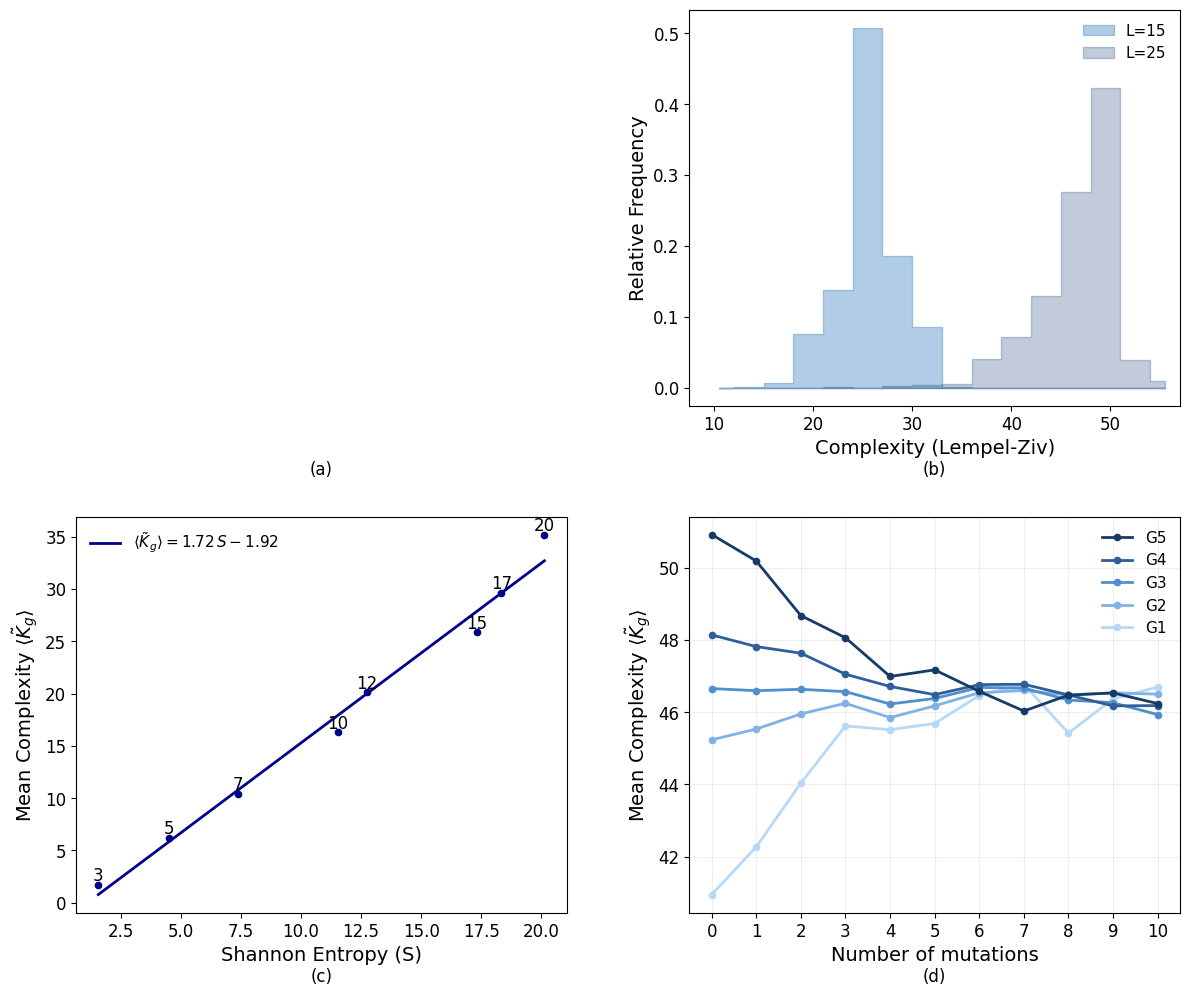

In [180]:
import matplotlib.pyplot as plt

# ===================================
# Create master figure: wide top + 2 bottom
# ===================================
fig = plt.figure(figsize=(12, 10))

ax_blank = plt.subplot2grid((2, 2), (0, 0))
ax_top   = plt.subplot2grid((2, 2), (0, 1))

ax_bl    = plt.subplot2grid((2, 2), (1, 0))
ax_br    = plt.subplot2grid((2, 2), (1, 1))

# Hide the blank panel
ax_blank.axis("off")

# ===================================
# Plotting
# ===================================
plot_hp_g_top(ax_top)
plot_C(ax_bl)
plot_D(ax_br)

# ===================================
# Panel labels
# ===================================
axes = [ax_blank, ax_top, ax_bl, ax_br]
panel_labels = ['(a)', '(b)', '(c)', '(d)']

for ax, label in zip(axes, panel_labels):
    ax.text(
        0.5, -0.14, label,
        transform=ax.transAxes,
        ha='center', va='top',
        fontsize=13
    )

# ===================================
# Styling
# ===================================
LABEL_SIZE = 14
TICK_SIZE = 12
LEGEND_SIZE = 11
ANNOT_SIZE = 12

for ax in axes:
    ax.xaxis.label.set_size(LABEL_SIZE)
    ax.yaxis.label.set_size(LABEL_SIZE)
    ax.tick_params(labelsize=TICK_SIZE)

    legend = ax.get_legend()
    if legend is not None:
        for text in legend.get_texts():
            text.set_fontsize(LEGEND_SIZE)

    for text in ax.texts:
        text.set_fontsize(ANNOT_SIZE)

# ===================================
# Title + spacing
# ===================================

plt.tight_layout()
plt.subplots_adjust(hspace=0.28, wspace=0.25)

plt.show()

compare different lengths

Available lengths: [3, 5, 7, 10, 12, 15, 17, 20, 25]
n= 3: N=10,000, mean KC=1.729
n= 5: N=40,000, mean KC=6.213
n= 7: N=10,000, mean KC=10.395
n=10: N=40,000, mean KC=16.287
n=12: N=10,000, mean KC=20.132
n=15: N=306,299, mean KC=25.862
n=17: N=400,000, mean KC=29.641
n=20: N=600,000, mean KC=35.216
n=25: N=200,000, mean KC=44.400

Using equal subsample size: 10,000 per length


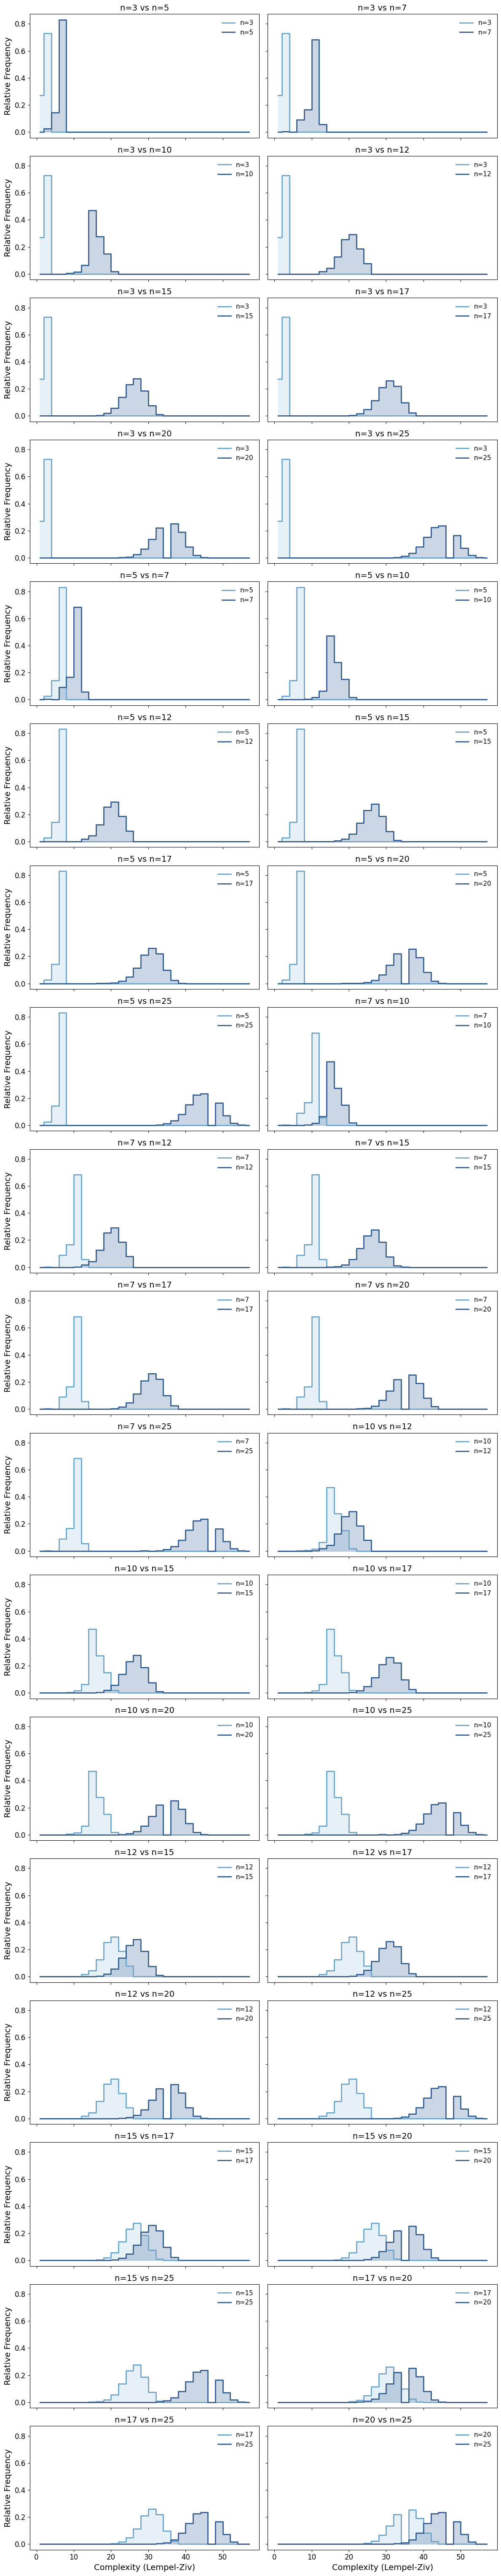

In [181]:
import re
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------
# Folder with HP raw datasets
# ------------------------------------------------------
base = Path(
    "/Users/sam/Documents/Oxford/Physics/sloppiness/"
    "circadian/mut_project_updates/figures/forsam3/HP_sizes"
)

# ------------------------------------------------------
# Helper: read one HP file
# ------------------------------------------------------
def load_hp_complexity(file_path):
    df = pd.read_csv(file_path, sep=r"\s+")
    df.columns = df.columns.str.strip()

    # complexity column in these files is KC
    x = pd.to_numeric(df["KC"], errors="coerce").dropna().to_numpy()
    x = x[x > 0]
    return x

# ------------------------------------------------------
# Collect all files and group them by length n
# Supports names like:
#   random_sample_mc_n3.txt
#   random_sample_mc_n17_set1.txt
#   random_sample_mc_n20_set1.txt
# ------------------------------------------------------
pattern = re.compile(r"random_sample_mc_n(\d+)(?:_set\d+)?\.txt$")

grouped = {}
for fp in sorted(base.glob("random_sample_mc_n*.txt")):
    m = pattern.match(fp.name)
    if not m:
        continue
    n = int(m.group(1))
    grouped.setdefault(n, []).append(load_hp_complexity(fp))

# Merge multiple sets for the same length, if present
data = {n: np.concatenate(arrs) for n, arrs in grouped.items()}
lengths = sorted(data.keys())

print("Available lengths:", lengths)
for n in lengths:
    print(f"n={n:>2}: N={len(data[n]):,}, mean KC={data[n].mean():.3f}")

# ------------------------------------------------------
# Equalize sample sizes across all lengths
# Use 50k if possible, otherwise the smallest available dataset
# ------------------------------------------------------
rng = np.random.default_rng(42)
print(f"\nUsing equal subsample size: {sample_n:,} per length")

sub = {}
sub = data

# ------------------------------------------------------
# Shared bins
# For HP complexity values, bin width 1 is usually a good start.
# If the plot looks too noisy, try 2 or 5.
# ------------------------------------------------------
all_values = np.concatenate(list(sub.values()))
bin_width = 2

bins = np.arange(
    np.floor(all_values.min() / bin_width) * bin_width,
    np.ceil(all_values.max() / bin_width) * bin_width + bin_width,
    bin_width,
)
centres = 0.5 * (bins[:-1] + bins[1:])

# ------------------------------------------------------
# Colors
# ------------------------------------------------------
light_fill = "#b7d4ea"
light_edge = "#6fa3c8"
dark_fill = "#6f8fb8"
dark_edge = "#355C8A"

# ------------------------------------------------------
# All pairwise comparisons
# WARNING: if you have many lengths, this can get large fast.
# ------------------------------------------------------
pairs = list(itertools.combinations(lengths, 2))
nplots = len(pairs)
ncols = 2
nrows = int(np.ceil(nplots / ncols))

fig, axs = plt.subplots(
    nrows,
    ncols,
    figsize=(12, 3.4 * nrows),
    sharex=True,
    sharey=True,
)

axs = np.ravel(axs)

for ax, (a, b) in zip(axs, pairs):
    ca, _ = np.histogram(sub[a], bins=bins)
    cb, _ = np.histogram(sub[b], bins=bins)

    ca = ca / ca.sum()
    cb = cb / cb.sum()

    ax.step(
        centres,
        ca,
        where="mid",
        lw=2,
        color=light_edge,
        label=f"n={a}",
    )
    ax.fill_between(
        centres,
        ca,
        step="mid",
        alpha=0.35,
        color=light_fill,
    )

    ax.step(
        centres,
        cb,
        where="mid",
        lw=2,
        color=dark_edge,
        label=f"n={b}",
    )
    ax.fill_between(
        centres,
        cb,
        step="mid",
        alpha=0.35,
        color=dark_fill,
    )

    ax.set_title(f"n={a} vs n={b}")
    ax.legend(frameon=False)
    ax.set_axisbelow(True)
    ax.minorticks_off()

# Hide any unused axes
for ax in axs[nplots:]:
    ax.axis("off")

for ax in axs[max(0, nplots - ncols):]:
    ax.set_xlabel("Complexity (Lempel-Ziv)")

for ax in axs[::2]:
    ax.set_ylabel("Relative Frequency")

plt.tight_layout()
plt.show()

Cartoon

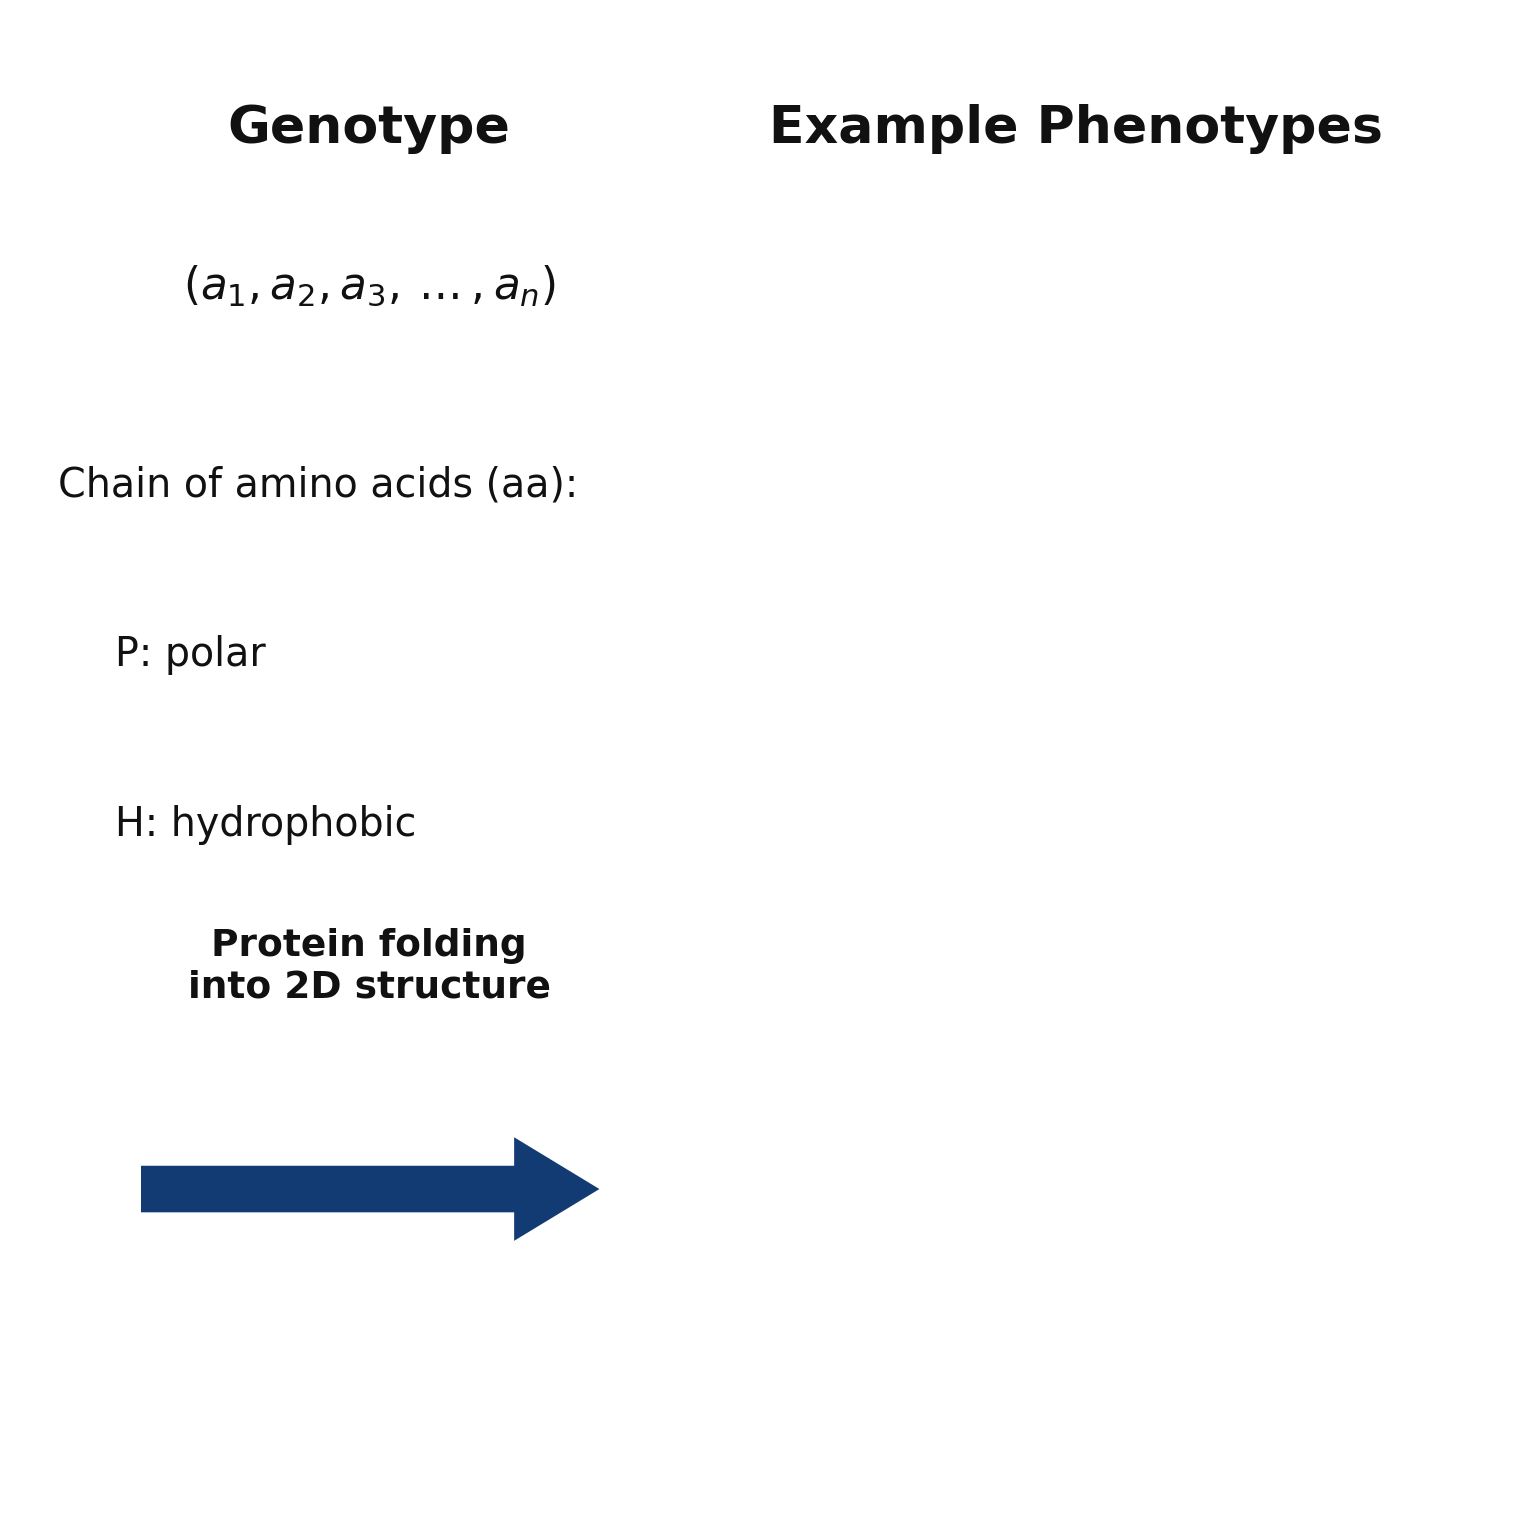

In [207]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Set publication typography & palette
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['pdf.fonttype'] = 42

NAVY = "#123A73"
MID_BLUE = "#4F79BC"
PALE_BLUE = "#DCE8F8"
DARK_TEXT = "#111111"

# 1:1 Square canvas dimensions
fig, ax = plt.subplots(figsize=(5.2, 5.2), dpi=300)
ax.set_xlim(0, 52)
ax.set_ylim(0, 52)
ax.axis('off')

# 1. HEADINGS
ax.text(12, 48, 'Genotype', fontsize=12.5, fontweight='bold', color=DARK_TEXT, ha='center')
ax.text(37, 48, 'Example Phenotypes', fontsize=12.5, fontweight='bold', color=DARK_TEXT, ha='center')

# 2. GENOTYPE CONTENT (Upper-left quadrant)
ax.text(12, 42.5, r'$(a_1, a_2, a_3, \dots, a_n)$', fontsize=10.5, color=DARK_TEXT, ha='center', fontstyle='italic')
ax.text(1, 35.5, 'Chain of amino acids (aa):', fontsize=9.5, color=DARK_TEXT, ha='left')
ax.text(3, 29.5, 'P: polar', fontsize=9.5, color=DARK_TEXT, ha='left')
ax.text(3, 23.5, 'H: hydrophobic', fontsize=9.5, color=DARK_TEXT, ha='left')

# 3. CENTRAL ARROW (Lower-left quadrant)
ax.text(12, 17.5, 'Protein folding\ninto 2D structure', fontsize=9.0, fontweight='bold', color=DARK_TEXT, ha='center', va='bottom')
arrow = mpatches.FancyArrow(4, 11, 16, 0, width=1.5, head_width=3.4, head_length=2.8, 
                            length_includes_head=True, facecolor=NAVY, edgecolor=NAVY)
ax.add_patch(arrow)

# 4. PHENOTYPE LATTICES (2 columns x 3 rows grid on the right)
def draw_hp_fold(ax, center_x, center_y, grid_coords, scale=1.35, node_types=None):
    x_c = [center_x + x * scale for x, y in grid_coords]
    y_c = [center_y + y * scale for x, y in grid_coords]
    
    # Draw backbone
    ax.plot(x_c, y_c, color=NAVY, lw=1.5, zorder=1)
    
    # Draw colored nodes
    for idx, (x, y) in enumerate(zip(x_c, y_c)):
        is_h = (idx % 2 == 0) if node_types is None else (node_types[idx] == 'H')
        fc = MID_BLUE if is_h else PALE_BLUE
        circle = mpatches.Circle((x, y), scale * 0.35, facecolor=fc, edgecolor=NAVY, lw=1.0, zorder=2)
        ax.add_patch(circle)
PHENO_DY = 7
# Row 1 (Top)
# 1. Main Central Fold
draw_hp_fold(ax, 61, 20 + PHENO_DY, central_fold_coords)

# 2. Bottom-Left Fold
draw_hp_fold(ax, 63, 6 + PHENO_DY, bottom_left_coords)

# 3. Middle Small Fold
draw_hp_fold(ax, 71, 35 + PHENO_DY, middle_small_coords)

# 4. Top-Right Straight Line
draw_hp_fold(ax, 84, 45 + PHENO_DY, top_right_coords)

# 5. Right-Hand Winding Fold
draw_hp_fold(ax, 82, 14 + PHENO_DY, right_fold_coords)

plt.tight_layout()
plt.savefig("HP_Square_Final.pdf", bbox_inches="tight", transparent=True)
plt.savefig("HP_Square_Final.png", dpi=300, bbox_inches="tight")

# View directly in environment
plt.show()

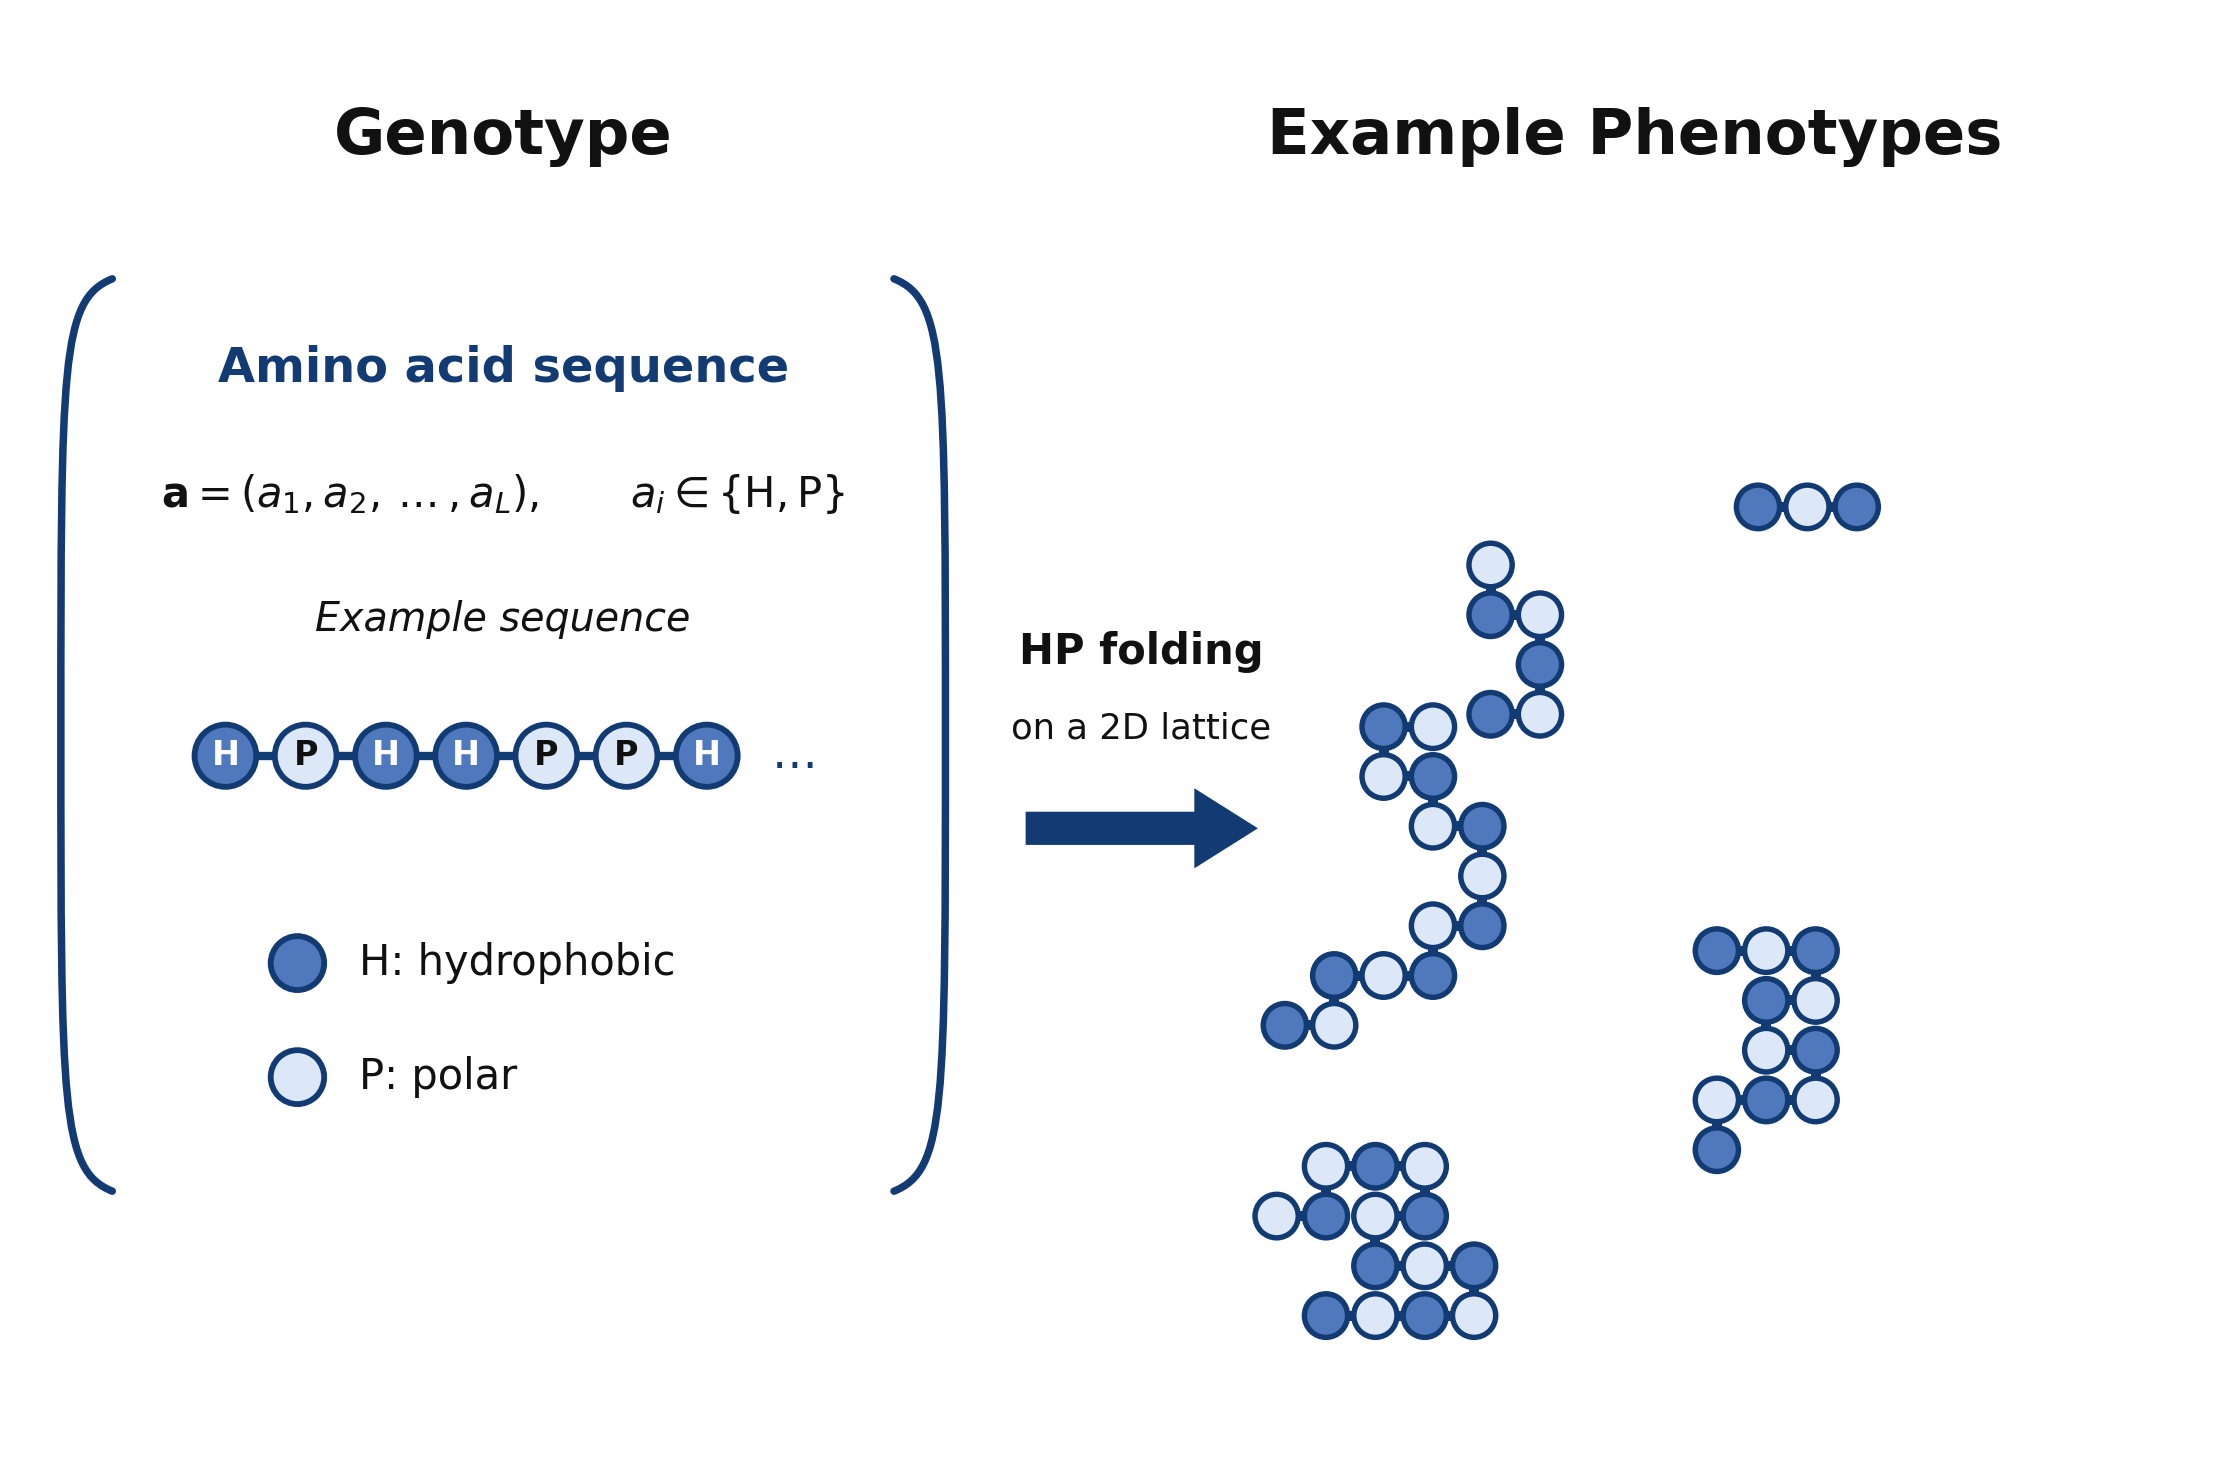

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.path import Path
import numpy as np

# Set publication typography & palette
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['pdf.fonttype'] = 42

NAVY = "#123A73"
MID_BLUE = "#4F79BC"
PALE_BLUE = "#DCE8F8"
DARK_TEXT = "#111111"

fig, ax = plt.subplots(figsize=(7.5, 5.0), dpi=300)
ax.set_xlim(0, 105)
ax.set_ylim(0, 68)
ax.axis('off')

# -------------------------------------------------------------------------
# 1. MAIN HEADINGS
# -------------------------------------------------------------------------
ax.text(23, 62, 'Genotype', fontsize=15, fontweight='bold', color=DARK_TEXT, ha='center')
ax.text(
    78,
    60.5,
    'Example Phenotypes',
    fontsize=15,
    fontweight='bold',
    color=DARK_TEXT,
    ha='center'
)
PHENO_DY = 7

# -------------------------------------------------------------------------
# 2. BRACKETED GENOTYPE CONTAINER
# -------------------------------------------------------------------------
def draw_bracket(ax, x_center, y_top, y_bottom, is_left=True, color=NAVY, lw=1.8):
    direction = -1 if is_left else 1
    depth = 2.5 * direction
    path_data = [
        (Path.MOVETO, (x_center, y_top)),
        (Path.CURVE4, (x_center + depth, y_top - 1)),
        (Path.CURVE4, (x_center + depth, y_top - 4)),
        (Path.CURVE4, (x_center + depth, (y_top + y_bottom) / 2)),
        (Path.LINETO, (x_center + depth, (y_top + y_bottom) / 2)),
        (Path.CURVE4, (x_center + depth, y_bottom + 4)),
        (Path.CURVE4, (x_center + depth, y_bottom + 1)),
        (Path.CURVE4, (x_center, y_bottom)),
    ]
    codes, verts = zip(*path_data)
    path = Path(verts, codes)
    patch = mpatches.PathPatch(path, facecolor='none', edgecolor=color, lw=lw, capstyle='round')
    ax.add_patch(patch)

draw_bracket(ax, x_center=4, y_top=56, y_bottom=12, is_left=True, color=NAVY, lw=1.8)
draw_bracket(ax, x_center=42, y_top=56, y_bottom=12, is_left=False, color=NAVY, lw=1.8)

# Header & Mathematical Definition
ax.text(23, 51, 'Amino acid sequence', fontsize=11.5, fontweight='bold', color=NAVY, ha='center')
ax.text(23, 45, r'$\mathbf{a}=(a_1,a_2,\dots,a_L),\qquad a_i\in\{\mathrm{H},\mathrm{P}\}$', fontsize=10, color=DARK_TEXT, ha='center')

# "Example sequence" sub-label
ax.text(23, 39, 'Example sequence', fontsize=9.5, color=DARK_TEXT, ha='center', style='italic')

# Sequence chain
seq_types = ['H', 'P', 'H', 'H', 'P', 'P', 'H']
x_start, y_seq = 9.5, 33
x_step = 3.9

ax.plot([x_start, x_start + 6 * x_step], [y_seq, y_seq], color=NAVY, lw=2.0, zorder=1)

for i, t in enumerate(seq_types):
    cx = x_start + i * x_step
    fc = MID_BLUE if t == 'H' else PALE_BLUE
    tc = "white" if t == 'H' else DARK_TEXT
    circle = mpatches.Circle((cx, y_seq), 1.5, facecolor=fc, edgecolor=NAVY, lw=1.4, zorder=2)
    ax.add_patch(circle)
    ax.text(cx, y_seq, t, fontsize=8, fontweight='bold', color=tc, ha='center', va='center', zorder=3)

ax.text(x_start + 6.7 * x_step, y_seq, r'$\dots$', fontsize=11, fontweight='bold', color=NAVY, va='center')

# Legend inside bracket
circle_h = mpatches.Circle((13, 23), 1.3, facecolor=MID_BLUE, edgecolor=NAVY, lw=1.4)
ax.add_patch(circle_h)
ax.text(16, 23, 'H: hydrophobic', fontsize=10, color=DARK_TEXT, va='center')

circle_p = mpatches.Circle((13, 17.5), 1.3, facecolor=PALE_BLUE, edgecolor=NAVY, lw=1.4)
ax.add_patch(circle_p)
ax.text(16, 17.5, 'P: polar', fontsize=10, color=DARK_TEXT, va='center')

# -------------------------------------------------------------------------
# 3. CENTERED ARROW & MAPPING LABEL
# -------------------------------------------------------------------------
arrow_mid_x = 54.0
ax.text(arrow_mid_x, 37, 'HP folding', fontsize=10, fontweight='bold', color=DARK_TEXT, ha='center', va='bottom')
ax.text(arrow_mid_x, 33.5, 'on a 2D lattice', fontsize=8.5, color=DARK_TEXT, ha='center', va='bottom')

arrow = mpatches.FancyArrow(48.5, 29.5, 11, 0, width=1.4, head_width=3.5, head_length=2.8, 
                            length_includes_head=True, facecolor=NAVY, edgecolor=NAVY)
ax.add_patch(arrow)

# -------------------------------------------------------------------------
# 4. LARGER CIRCLES & TIGHTLY CLUSTERED PHENOTYPES
# -------------------------------------------------------------------------
UNIFORM_SCALE = 2.4       # Grid step spacing
UNIFORM_BOND_LW = 2.4     # Backbone line weight
UNIFORM_NODE_R = 1.05     # Enlarged node radius

def draw_hp_fold(ax, center_x, center_y, grid_coords, node_types=None):
    x_c = [center_x + x * UNIFORM_SCALE for x, y in grid_coords]
    y_c = [center_y + y * UNIFORM_SCALE for x, y in grid_coords]
    
    # Backbone
    ax.plot(x_c, y_c, color=NAVY, lw=UNIFORM_BOND_LW, zorder=1)
    
    # Colored nodes alternating H and P
    for idx, (x, y) in enumerate(zip(x_c, y_c)):
        is_h = (idx % 2 == 0) if node_types is None else (node_types[idx] == 'H')
        fc = MID_BLUE if is_h else PALE_BLUE
        circle = mpatches.Circle((x, y), UNIFORM_NODE_R, facecolor=fc, edgecolor=NAVY, lw=1.3, zorder=2)
        ax.add_patch(circle)

# Exact walks extracted from your image:

# 1. Main Central Fold
central_fold_coords = [
    (0,0), (1,0), (1,1), (2,1), (3,1), (3,2), (4,2), (4,3), (4,4), 
    (3,4), (3,5), (2,5), (2,6), (3,6)
]
draw_hp_fold(ax, 61, 20, central_fold_coords)

# 2. Bottom-Left Fold
bottom_left_coords = [
    (0,0), (1,0), (2,0), (3,0), (3,1), (2,1), (1,1), (1,2), 
    (2,2), (2,3), (1,3), (0,3), (0,2), (-1,2)
]
draw_hp_fold(ax, 63, 6, bottom_left_coords)

# 3. Middle Small Fold
middle_small_coords = [
    (0,0), (1,0), (1,1), (1,2), (0,2), (0,3)
]
draw_hp_fold(ax, 71, 35, middle_small_coords)

# 4. Top-Right Straight Line
top_right_coords = [
    (0,0), (1,0), (2,0)
]
draw_hp_fold(ax, 84, 45, top_right_coords)

# 5. Right-Hand Winding Fold
right_fold_coords = [
    (0,0), (0,1), (1,1), (2,1), (2,2), (1,2), (1,3), (2,3), (2,4), (1,4), (0,4)
]
draw_hp_fold(ax, 82, 14, right_fold_coords)

plt.tight_layout()
plt.savefig("HP_Exact_Patterns_Perfect.pdf", bbox_inches="tight", transparent=True)
plt.savefig("HP_Exact_Patterns_Perfect.png", dpi=300, bbox_inches="tight")
plt.show()

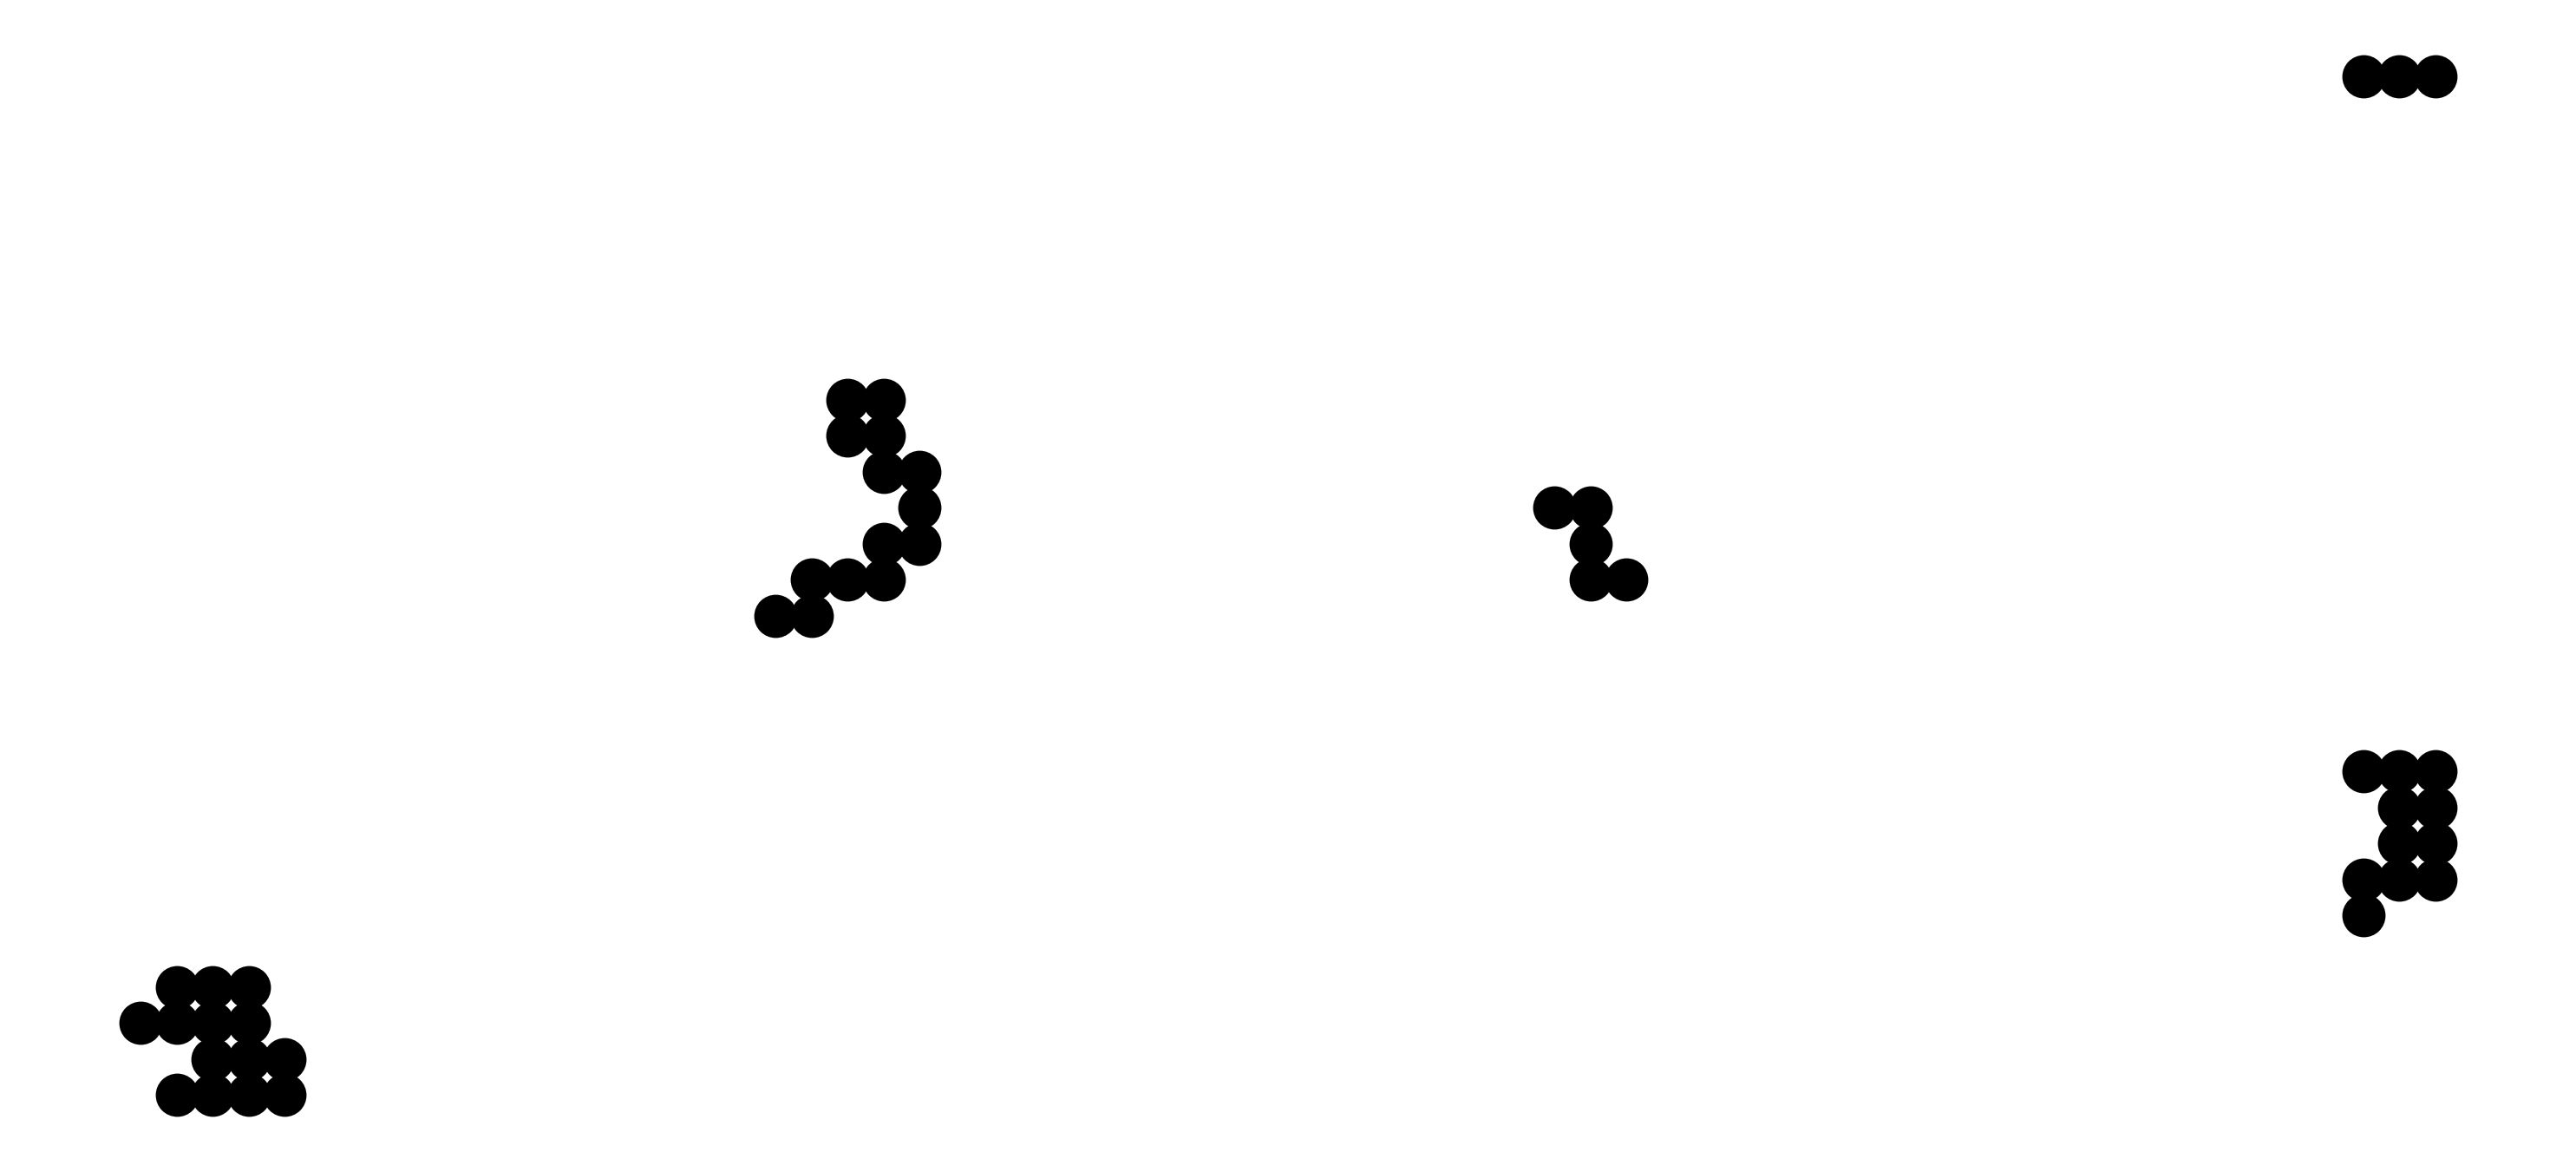

In [ ]:
draw_headings(ax)
draw_genotype(ax)
draw_arrow(ax)
add_svg(ax, "figsA_HP.svg", x=58, y=8, width=38)

In [205]:
pip install svgpath2mpl svgpathtools


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
